# Project VI - Priority-A Correlated Astrometric Monte Carlo

This notebook runs the first correlated astrometric Monte Carlo for exactly two Project VI `validation_priority_A` candidates. It propagates Gaia DR3 parallax, pmra, and pmdec jointly using the retrieved covariance matrices. RA, Dec, and the LAMOST radial-velocity central value are fixed. This is not full six-dimensional observational uncertainty propagation.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.coordinates import SkyCoord, Galactocentric
from galpy.orbit import Orbit
from galpy.potential import MWPotential2014

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

CWD = Path.cwd().resolve()
ROOT = CWD.parent if CWD.name == "notebooks" else CWD
DATA = ROOT / "data" / "processed"
FIG = ROOT / "figures"
REPORT = ROOT / "report"
FIG.mkdir(exist_ok=True)
REPORT.mkdir(exist_ok=True)

TARGET_IDS = ["3089847099636770560", "3089534353001157632"]
TARGET_ID_SET = set(TARGET_IDS)
MC_MODE = "correlated_gaia_astrometry_rv_fixed"
BASELINE_MODE = "measured_only_parallax"
N_DRAWS = 200
RNG_SEED = 20260804
VARIABLE_ORDER = ["parallax_mas", "pmra_masyr", "pmdec_masyr"]

OUT_DRAWS = DATA / "project_vi_correlated_mc_draws.csv"
OUT_SUMMARY = DATA / "project_vi_correlated_mc_candidate_summary.csv"
OUT_MODE_COMPARISON = DATA / "project_vi_correlated_mc_mode_comparison.csv"
FIG_L = FIG / "project_vi_correlated_mc_lz_lperp.png"
FIG_ORBIT = FIG / "project_vi_correlated_mc_orbit_uncertainty.png"
FIG_MODE = FIG / "project_vi_mc_mode_comparison.png"
OUT_REPORT = REPORT / "project_vi_priority_a_correlated_astrometric_mc.md"

print("Project root:", ROOT)
print("Mode:", MC_MODE)
print("Variable order:", VARIABLE_ORDER)
print("Draws per target:", N_DRAWS, "seed:", RNG_SEED)

Project root: /Users/liors/Documents/research/gaia-lamost-galactic-archaeology
Mode: correlated_gaia_astrometry_rv_fixed
Variable order: ['parallax_mas', 'pmra_masyr', 'pmdec_masyr']
Draws per target: 200 seed: 20260804


In [2]:
cov_inputs = pd.read_csv(DATA / "project_vi_priority_a_covariance_inputs.csv", dtype={"source_id": "string"})
reference = pd.read_csv(DATA / "project_ii_galpy_orbit_candidates.csv", dtype={"source_id": "string"})
priority = pd.read_csv(DATA / "project_vi_validation_priority_candidates.csv", dtype={"source_id": "string"})
parallax_only = pd.read_csv(DATA / "project_vi_mc_prototype_candidate_uncertainties.csv", dtype={"source_id": "string"})

for df in [cov_inputs, reference, priority, parallax_only]:
    df["source_id"] = df["source_id"].astype("string").str.replace(r"\.0$", "", regex=True)

cov_inputs = cov_inputs[cov_inputs["source_id"].isin(TARGET_ID_SET)].copy().sort_values("source_id").reset_index(drop=True)
assert len(cov_inputs) == 2
assert set(cov_inputs["source_id"]) == TARGET_ID_SET
assert cov_inputs["source_id"].is_unique
assert (cov_inputs["covariance_variable_order"] == ", ".join(VARIABLE_ORDER)).all()
assert cov_inputs["covariance_ready"].all()
assert not cov_inputs["rv_uncertainty_ready"].any()

reference_targets = reference[reference["source_id"].isin(TARGET_ID_SET)].copy()
priority_targets = priority[priority["source_id"].isin(TARGET_ID_SET)].copy()
parallax_only_targets = parallax_only[parallax_only["source_id"].isin(TARGET_ID_SET)].copy()

cov_inputs[["source_id", "parallax_mas", "pmra_masyr", "pmdec_masyr", "rv_central_kms", "covariance_variable_order", "covariance_ready", "rv_uncertainty_ready"]]

,source_id,parallax_mas,pmra_masyr,pmdec_masyr,rv_central_kms,covariance_variable_order,covariance_ready,rv_uncertainty_ready
0,3089534353001157632,0.458766,2.906364,-36.283028,-43.26,"parallax_mas, pmra_masyr, pmdec_masyr",True,False
1,3089847099636770560,0.637151,-42.072760,-36.356421,-11.29,"parallax_mas, pmra_masyr, pmdec_masyr",True,False


In [3]:
def covariance_from_row(row):
    sigmas = np.array([row["parallax_error_mas"], row["pmra_error_masyr"], row["pmdec_error_masyr"]], dtype=float)
    corr = np.array([
        [1.0, row["parallax_pmra_corr"], row["parallax_pmdec_corr"]],
        [row["parallax_pmra_corr"], 1.0, row["pmra_pmdec_corr"]],
        [row["parallax_pmdec_corr"], row["pmra_pmdec_corr"], 1.0],
    ], dtype=float)
    cov = corr * np.outer(sigmas, sigmas)
    return sigmas, corr, cov

# Confirm reconstruction matches the saved covariance elements from retrieval.
for _, row in cov_inputs.iterrows():
    _, _, cov = covariance_from_row(row)
    saved = np.array([[row["cov_00"], row["cov_01"], row["cov_02"]], [row["cov_10"], row["cov_11"], row["cov_12"]], [row["cov_20"], row["cov_21"], row["cov_22"]]], dtype=float)
    assert np.allclose(cov, saved, rtol=1e-12, atol=1e-16), row["source_id"]
    assert np.allclose(cov, cov.T, rtol=0, atol=1e-14)
    assert np.linalg.eigvalsh(cov).min() >= -1e-14
print("Covariance matrices match retrieval inputs.")

Covariance matrices match retrieval inputs.


In [4]:
def compute_angular_momentum(ra_deg, dec_deg, distance_kpc, pmra_masyr, pmdec_masyr, rv_kms):
    coord = SkyCoord(
        ra=ra_deg * u.deg,
        dec=dec_deg * u.deg,
        distance=distance_kpc * u.kpc,
        pm_ra_cosdec=pmra_masyr * u.mas / u.yr,
        pm_dec=pmdec_masyr * u.mas / u.yr,
        radial_velocity=rv_kms * u.km / u.s,
        frame="icrs",
    )
    galcen = coord.transform_to(Galactocentric()).cartesian
    diff = galcen.differentials[next(iter(galcen.differentials.keys()))]
    x = galcen.x.to_value(u.kpc)
    y = galcen.y.to_value(u.kpc)
    z = galcen.z.to_value(u.kpc)
    vx = diff.d_x.to_value(u.km / u.s)
    vy = diff.d_y.to_value(u.km / u.s)
    vz = diff.d_z.to_value(u.km / u.s)
    Lx = y * vz - z * vy
    Ly = z * vx - x * vz
    Lz = x * vy - y * vx
    Lperp = np.sqrt(Lx**2 + Ly**2)
    Ltot = np.sqrt(Lx**2 + Ly**2 + Lz**2)
    return {"Lx_kpc_kms": float(Lx), "Ly_kpc_kms": float(Ly), "Lz_kpc_kms": float(Lz), "Lperp_kpc_kms": float(Lperp), "Ltot_kpc_kms": float(Ltot)}

def integrate_orbit(ra_deg, dec_deg, distance_kpc, pmra_masyr, pmdec_masyr, rv_kms):
    orbit = Orbit(vxvv=[ra_deg, dec_deg, distance_kpc, pmra_masyr, pmdec_masyr, rv_kms], radec=True, ro=8.2, vo=232.0, solarmotion="schoenrich")
    ts = np.linspace(0, 5, 1001) * u.Gyr
    orbit.integrate(ts, MWPotential2014)
    return {"galpy_eccentricity": float(orbit.e()), "galpy_rperi_kpc": float(orbit.rperi()), "galpy_rap_kpc": float(orbit.rap()), "galpy_zmax_kpc": float(orbit.zmax()), "galpy_energy": float(orbit.E())}

def compute_all(ra_deg, dec_deg, parallax_mas, pmra_masyr, pmdec_masyr, rv_kms):
    if parallax_mas <= 0:
        raise ValueError("nonpositive_parallax")
    distance_kpc = 1.0 / parallax_mas
    out = {"distance_kpc_draw": float(distance_kpc)}
    out.update(compute_angular_momentum(ra_deg, dec_deg, distance_kpc, pmra_masyr, pmdec_masyr, rv_kms))
    out.update(integrate_orbit(ra_deg, dec_deg, distance_kpc, pmra_masyr, pmdec_masyr, rv_kms))
    return out

In [5]:
rng = np.random.default_rng(RNG_SEED)
draw_rows = []

for _, row in cov_inputs.iterrows():
    mean = np.array([row["parallax_mas"], row["pmra_masyr"], row["pmdec_masyr"]], dtype=float)
    _, _, cov = covariance_from_row(row)
    draws = rng.multivariate_normal(mean, cov, size=N_DRAWS)
    for draw_index, (parallax_draw, pmra_draw, pmdec_draw) in enumerate(draws):
        base = {
            "source_id": row["source_id"],
            "mc_mode": MC_MODE,
            "draw_index": draw_index,
            "variable_order": ", ".join(VARIABLE_ORDER),
            "parallax_draw_mas": float(parallax_draw),
            "pmra_draw_masyr": float(pmra_draw),
            "pmdec_draw_masyr": float(pmdec_draw),
            "parallax_reference_mas": float(row["parallax_mas"]),
            "pmra_reference_masyr": float(row["pmra_masyr"]),
            "pmdec_reference_masyr": float(row["pmdec_masyr"]),
            "ra_fixed_deg": float(row["ra_deg"]),
            "dec_fixed_deg": float(row["dec_deg"]),
            "radial_velocity_fixed_kms": float(row["rv_central_kms"]),
            "valid_draw": False,
            "rejection_reason": "",
        }
        if parallax_draw <= 0:
            base["rejection_reason"] = "nonpositive_parallax"
            draw_rows.append(base)
            continue
        try:
            base.update(compute_all(row["ra_deg"], row["dec_deg"], parallax_draw, pmra_draw, pmdec_draw, row["rv_central_kms"]))
            base["valid_draw"] = True
        except Exception as exc:
            base["rejection_reason"] = f"orbit_failure:{type(exc).__name__}"
        draw_rows.append(base)

draws_df = pd.DataFrame(draw_rows)
draws_df.to_csv(OUT_DRAWS, index=False)
print("Saved", OUT_DRAWS, draws_df.shape)
draws_df.groupby(["source_id", "valid_draw"], dropna=False).size().unstack(fill_value=0)

Saved /Users/liors/Documents/research/gaia-lamost-galactic-archaeology/data/processed/project_vi_correlated_mc_draws.csv (400, 26)


valid_draw,True
source_id,
3089534353001157632,200
3089847099636770560,200


In [6]:
METRICS = {"Lz_kpc_kms": "Lz", "Lperp_kpc_kms": "Lperp", "Ltot_kpc_kms": "Ltot", "galpy_eccentricity": "eccentricity", "galpy_rperi_kpc": "rperi", "galpy_rap_kpc": "rap", "galpy_zmax_kpc": "Zmax"}

summary_rows = []
for _, row in cov_inputs.iterrows():
    sid = row["source_id"]
    valid = draws_df[(draws_df["source_id"] == sid) & (draws_df["valid_draw"])]
    rejected = draws_df[(draws_df["source_id"] == sid) & (~draws_df["valid_draw"])]
    ref_row = reference_targets[reference_targets["source_id"] == sid].iloc[0]
    pr_row = priority_targets[priority_targets["source_id"] == sid].iloc[0]
    out = {
        "source_id": sid,
        "mc_mode": MC_MODE,
        "random_seed": RNG_SEED,
        "n_draws_requested": N_DRAWS,
        "n_draws_valid": int(len(valid)),
        "n_draws_rejected": int(len(rejected)),
        "n_draws_rejected_nonpositive_parallax": int((rejected.get("rejection_reason", pd.Series(dtype=str)) == "nonpositive_parallax").sum()),
        "success_fraction": float(len(valid) / N_DRAWS),
        "variable_order": ", ".join(VARIABLE_ORDER),
        "ra_fixed_deg": float(row["ra_deg"]),
        "dec_fixed_deg": float(row["dec_deg"]),
        "rv_fixed_kms": float(row["rv_central_kms"]),
        "rv_source": row["rv_central_source"],
        "rv_uncertainty_used": False,
        "ra_dec_uncertainty_used": False,
        "project_iii_population_label": pr_row["project_iii_population_label"],
        "project_iii_population_group": pr_row["project_iii_population_group"],
        "classification_threshold_note": "diagnostic only; thresholds traced to existing Project II/III simple rules",
        "prob_Lz_lt_0": float((valid["Lz_kpc_kms"] < 0).mean()),
        "prob_Lz_lt_minus_500": float((valid["Lz_kpc_kms"] < -500).mean()),
        "prob_Lz_lt_500": float((valid["Lz_kpc_kms"] < 500).mean()),
        "prob_Lz_gt_500": float((valid["Lz_kpc_kms"] > 500).mean()),
        "prob_abs_Lz_lt_500": float((valid["Lz_kpc_kms"].abs() < 500).mean()),
        "prob_ecc_ge_0p7": float((valid["galpy_eccentricity"] >= 0.7).mean()),
        "prob_Zmax_gt_3kpc": float((valid["galpy_zmax_kpc"] > 3).mean()),
    }
    for metric, short in METRICS.items():
        vals = pd.to_numeric(valid[metric], errors="coerce").dropna()
        p16, med, p84 = np.percentile(vals, [16, 50, 84])
        out[f"{short}_reference"] = float(pd.to_numeric(ref_row[metric], errors="coerce"))
        out[f"{short}_mc_median"] = float(med)
        out[f"{short}_mc_p16"] = float(p16)
        out[f"{short}_mc_p84"] = float(p84)
        out[f"{short}_mc_interval_width"] = float(p84 - p16)
        out[f"{short}_mc_lower_uncertainty"] = float(med - p16)
        out[f"{short}_mc_upper_uncertainty"] = float(p84 - med)
    summary_rows.append(out)

summary = pd.DataFrame(summary_rows)
summary.to_csv(OUT_SUMMARY, index=False)
print("Saved", OUT_SUMMARY, summary.shape)
summary[["source_id", "success_fraction", "prob_Lz_lt_minus_500", "prob_abs_Lz_lt_500", "prob_ecc_ge_0p7", "prob_Zmax_gt_3kpc", "Lz_mc_median", "Lz_mc_p16", "Lz_mc_p84"]]

Saved /Users/liors/Documents/research/gaia-lamost-galactic-archaeology/data/processed/project_vi_correlated_mc_candidate_summary.csv (2, 74)


,source_id,success_fraction,prob_Lz_lt_minus_500,prob_abs_Lz_lt_500,prob_ecc_ge_0p7,prob_Zmax_gt_3kpc,Lz_mc_median,Lz_mc_p16,Lz_mc_p84
0,3089534353001157632,1.0,0.0,0.615,1.00,1.0,464.952659,331.820633,621.955556
1,3089847099636770560,1.0,1.0,0.000,0.58,1.0,-958.468427,-1003.245192,-908.164620


In [7]:
comparison_rows = []
for _, row in summary.iterrows():
    sid = row["source_id"]
    baseline = parallax_only_targets[parallax_only_targets["source_id"] == sid].iloc[0]
    for metric, short in METRICS.items():
        base_med = baseline[f"{short}_mc_median"]
        base_p16 = baseline[f"{short}_mc_p16"]
        base_p84 = baseline[f"{short}_mc_p84"]
        corr_med = row[f"{short}_mc_median"]
        corr_p16 = row[f"{short}_mc_p16"]
        corr_p84 = row[f"{short}_mc_p84"]
        comparison_rows.append({
            "source_id": sid,
            "metric": short,
            "unit": "kpc km/s" if short in ["Lz", "Lperp", "Ltot"] else ("kpc" if short in ["rperi", "rap", "Zmax"] else "dimensionless"),
            "baseline_mode": BASELINE_MODE,
            "correlated_mode": MC_MODE,
            "baseline_success_fraction": baseline["success_fraction"],
            "correlated_success_fraction": row["success_fraction"],
            "baseline_median": base_med,
            "baseline_p16": base_p16,
            "baseline_p84": base_p84,
            "baseline_interval_width": base_p84 - base_p16,
            "correlated_median": corr_med,
            "correlated_p16": corr_p16,
            "correlated_p84": corr_p84,
            "correlated_interval_width": corr_p84 - corr_p16,
            "median_shift_correlated_minus_baseline": corr_med - base_med,
            "interval_width_change_correlated_minus_baseline": (corr_p84 - corr_p16) - (base_p84 - base_p16),
            "interval_width_ratio_correlated_over_baseline": (corr_p84 - corr_p16) / (base_p84 - base_p16) if (base_p84 - base_p16) != 0 else np.nan,
        })
comparison = pd.DataFrame(comparison_rows)
comparison.to_csv(OUT_MODE_COMPARISON, index=False)
print("Saved", OUT_MODE_COMPARISON, comparison.shape)
comparison.head(14)

Saved /Users/liors/Documents/research/gaia-lamost-galactic-archaeology/data/processed/project_vi_correlated_mc_mode_comparison.csv (14, 18)


,source_id,metric,unit,baseline_mode,correlated_mode,baseline_success_fraction,correlated_success_fraction,baseline_median,baseline_p16,baseline_p84,baseline_interval_width,correlated_median,correlated_p16,correlated_p84,correlated_interval_width,median_shift_correlated_minus_baseline,interval_width_change_correlated_minus_baseline,interval_width_ratio_correlated_over_baseline
0,3089534353001157632,Lz,kpc km/s,measured_only_parallax,correlated_gaia_astrometry_rv_fixed,1.0,1.0,448.815021,331.999507,592.762585,260.763077,464.952659,331.820633,621.955556,290.134924,16.137639,29.371846,1.112638
1,3089534353001157632,Lperp,kpc km/s,measured_only_parallax,correlated_gaia_astrometry_rv_fixed,1.0,1.0,1294.713462,1246.343930,1354.051781,107.707851,1302.086781,1246.697192,1367.721637,121.024445,7.373320,13.316594,1.123636
2,3089534353001157632,Ltot,kpc km/s,measured_only_parallax,correlated_gaia_astrometry_rv_fixed,1.0,1.0,1370.298481,1289.805029,1478.116328,188.311298,1383.235179,1289.909618,1502.598832,212.689214,12.936698,24.377915,1.129455
3,3089534353001157632,eccentricity,dimensionless,measured_only_parallax,correlated_gaia_astrometry_rv_fixed,1.0,1.0,0.838932,0.817288,0.868049,0.050760,0.837566,0.814488,0.864322,0.049834,-0.001366,-0.000926,0.981748
4,3089534353001157632,rperi,kpc,measured_only_parallax,correlated_gaia_astrometry_rv_fixed,1.0,1.0,1.889432,1.435626,2.359922,0.924296,1.924076,1.482407,2.434435,0.952028,0.034643,0.027732,1.030004
5,3089534353001157632,rap,kpc,measured_only_parallax,correlated_gaia_astrometry_rv_fixed,1.0,1.0,21.631025,20.307359,23.519599,3.212240,21.827567,20.305567,23.941180,3.635613,0.196542,0.423373,1.131800
6,3089534353001157632,Zmax,kpc,measured_only_parallax,correlated_gaia_astrometry_rv_fixed,1.0,1.0,17.649601,16.966221,18.618672,1.652451,17.731509,16.965290,18.879752,1.914463,0.081908,0.262012,1.158559
7,3089847099636770560,Lz,kpc km/s,measured_only_parallax,correlated_gaia_astrometry_rv_fixed,1.0,1.0,-961.345961,-1009.492712,-915.575352,93.917360,-958.468427,-1003.245192,-908.164620,95.080573,2.877534,1.163213,1.012385
8,3089847099636770560,Lperp,kpc km/s,measured_only_parallax,correlated_gaia_astrometry_rv_fixed,1.0,1.0,3530.831416,3371.536584,3682.459895,310.923311,3539.907644,3392.673567,3703.166645,310.493078,9.076227,-0.430233,0.998616
9,3089847099636770560,Ltot,kpc km/s,measured_only_parallax,correlated_gaia_astrometry_rv_fixed,1.0,1.0,3659.365618,3519.422765,3794.573639,275.150873,3667.526860,3537.902604,3813.717399,275.814795,8.161242,0.663922,1.002413


In [8]:
# Quality checks requested for this stage.
assert len(draws_df) == 2 * N_DRAWS
assert set(draws_df["source_id"]) == TARGET_ID_SET
assert set(summary["source_id"]) == TARGET_ID_SET
assert (summary["n_draws_requested"] == N_DRAWS).all()
assert (summary["success_fraction"] == summary["n_draws_valid"] / summary["n_draws_requested"]).all()
for short in ["Lz", "Lperp", "Ltot", "eccentricity", "rperi", "rap", "Zmax"]:
    assert (summary[f"{short}_mc_p16"] <= summary[f"{short}_mc_median"]).all(), short
    assert (summary[f"{short}_mc_median"] <= summary[f"{short}_mc_p84"]).all(), short

# Drawn variables must vary; fixed variables must remain fixed.
for _, row in cov_inputs.iterrows():
    sid = row["source_id"]
    sub = draws_df[draws_df["source_id"] == sid]
    assert sub["parallax_draw_mas"].std() > 0, sid
    assert sub["pmra_draw_masyr"].std() > 0, sid
    assert sub["pmdec_draw_masyr"].std() > 0, sid
    assert sub["ra_fixed_deg"].nunique() == 1, sid
    assert sub["dec_fixed_deg"].nunique() == 1, sid
    assert sub["radial_velocity_fixed_kms"].nunique() == 1, sid

assert set(comparison["metric"]) == set(METRICS.values())
assert set(comparison["source_id"]) == TARGET_ID_SET
print("All correlated MC quality checks passed.")

All correlated MC quality checks passed.


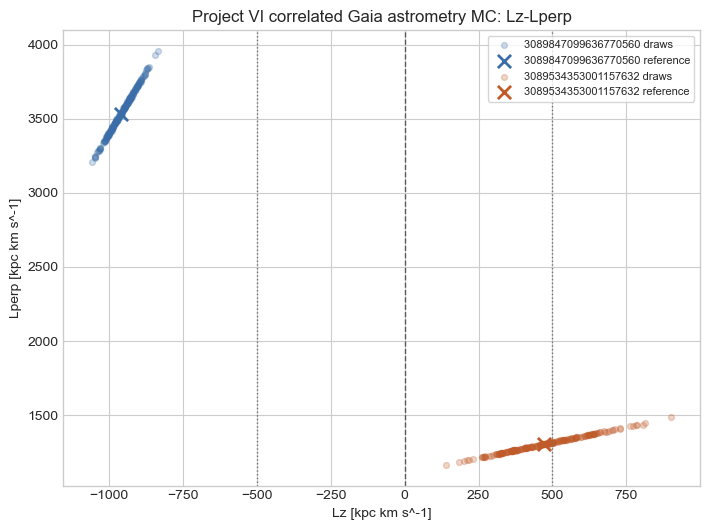

/Users/liors/Documents/research/gaia-lamost-galactic-archaeology/figures/project_vi_correlated_mc_lz_lperp.png


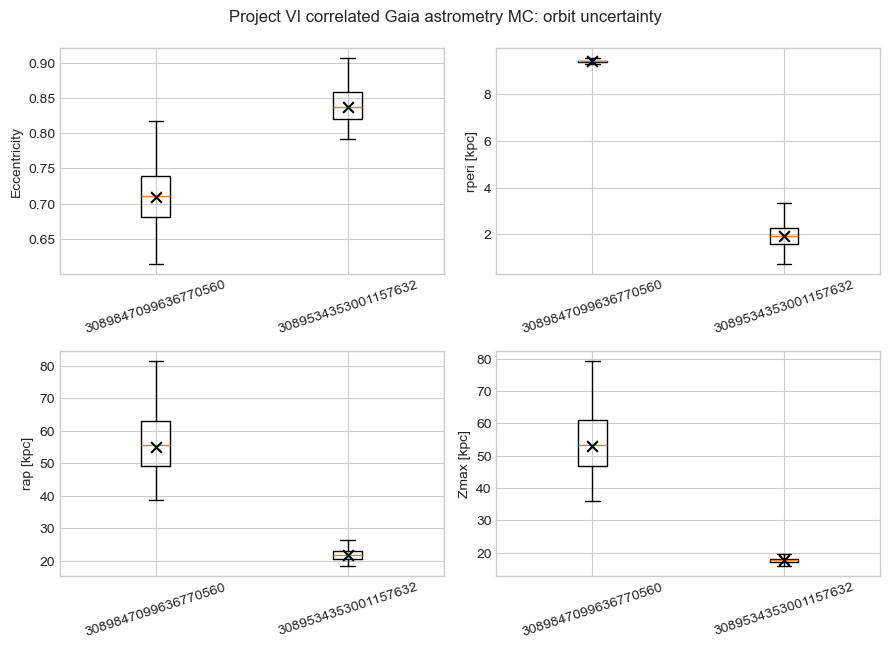

/Users/liors/Documents/research/gaia-lamost-galactic-archaeology/figures/project_vi_correlated_mc_orbit_uncertainty.png


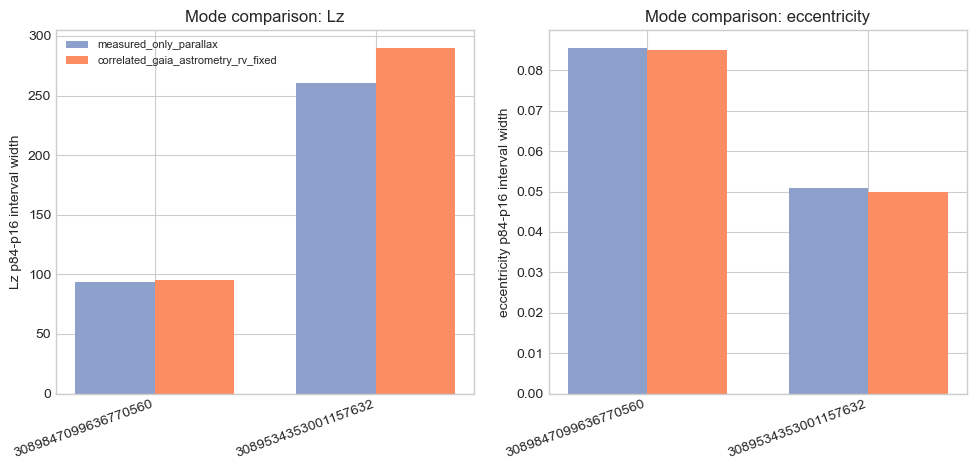

/Users/liors/Documents/research/gaia-lamost-galactic-archaeology/figures/project_vi_mc_mode_comparison.png


In [9]:
fig, ax = plt.subplots(figsize=(7.2, 5.4))
colors = {"3089847099636770560": "#3b6ea8", "3089534353001157632": "#c05a28"}
for sid in TARGET_IDS:
    valid = draws_df[(draws_df["source_id"] == sid) & (draws_df["valid_draw"])]
    ref = summary[summary["source_id"] == sid].iloc[0]
    ax.scatter(valid["Lz_kpc_kms"], valid["Lperp_kpc_kms"], s=18, alpha=0.25, color=colors[sid], label=f"{sid} draws")
    ax.scatter(ref["Lz_reference"], ref["Lperp_reference"], s=90, marker="x", color=colors[sid], linewidth=2.0, label=f"{sid} reference")
ax.axvline(0, color="0.35", linestyle="--", linewidth=1)
ax.axvline(-500, color="0.45", linestyle=":", linewidth=1)
ax.axvline(500, color="0.45", linestyle=":", linewidth=1)
ax.set_xlabel("Lz [kpc km s^-1]")
ax.set_ylabel("Lperp [kpc km s^-1]")
ax.set_title("Project VI correlated Gaia astrometry MC: Lz-Lperp")
ax.legend(fontsize=8, frameon=True)
fig.tight_layout()
fig.savefig(FIG_L, dpi=220)
plt.show()
print(FIG_L)

fig, axes = plt.subplots(2, 2, figsize=(9, 6.5))
plot_metrics = [("galpy_eccentricity", "Eccentricity"), ("galpy_rperi_kpc", "rperi [kpc]"), ("galpy_rap_kpc", "rap [kpc]"), ("galpy_zmax_kpc", "Zmax [kpc]")]
for ax, (metric, label) in zip(axes.ravel(), plot_metrics):
    data = [draws_df[(draws_df["source_id"] == sid) & (draws_df["valid_draw"])][metric].dropna().to_numpy() for sid in TARGET_IDS]
    ax.boxplot(data, labels=TARGET_IDS, showfliers=False)
    for i, sid in enumerate(TARGET_IDS, start=1):
        ref_short = {"galpy_eccentricity": "eccentricity", "galpy_rperi_kpc": "rperi", "galpy_rap_kpc": "rap", "galpy_zmax_kpc": "Zmax"}[metric]
        ref = summary[summary["source_id"] == sid].iloc[0][f"{ref_short}_reference"]
        ax.scatter(i, ref, color="black", marker="x", s=60, zorder=3)
    ax.set_ylabel(label)
    ax.tick_params(axis="x", labelrotation=18)
fig.suptitle("Project VI correlated Gaia astrometry MC: orbit uncertainty", y=0.99)
fig.tight_layout()
fig.savefig(FIG_ORBIT, dpi=220)
plt.show()
print(FIG_ORBIT)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.8), sharey=False)
for ax, metric in zip(axes, ["Lz", "eccentricity"]):
    sub = comparison[comparison["metric"] == metric]
    x = np.arange(len(TARGET_IDS))
    base_width = sub.set_index("source_id").loc[TARGET_IDS, "baseline_interval_width"].to_numpy()
    corr_width = sub.set_index("source_id").loc[TARGET_IDS, "correlated_interval_width"].to_numpy()
    ax.bar(x - 0.18, base_width, width=0.36, label=BASELINE_MODE, color="#8da0cb")
    ax.bar(x + 0.18, corr_width, width=0.36, label=MC_MODE, color="#fc8d62")
    ax.set_xticks(x)
    ax.set_xticklabels(TARGET_IDS, rotation=20, ha="right")
    ax.set_ylabel(f"{metric} p84-p16 interval width")
    ax.set_title(f"Mode comparison: {metric}")
axes[0].legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_MODE, dpi=220)
plt.show()
print(FIG_MODE)

In [10]:
def triplet(row, short):
    return f"{row[f'{short}_mc_median']:.6g} [{row[f'{short}_mc_p16']:.6g}, {row[f'{short}_mc_p84']:.6g}]"

lines = [
    "# Project VI - Priority-A Correlated Astrometric Monte Carlo",
    "",
    "## Scope",
    "",
    "This report documents a two-candidate correlated astrometric Monte Carlo for Project VI. The mode is `correlated_gaia_astrometry_rv_fixed`. It propagates Gaia DR3 `parallax`, `pmra`, and `pmdec` jointly using the retrieved Gaia correlation coefficients and standard uncertainties. RA, Dec, and the LAMOST radial-velocity central value are fixed.",
    "",
    "This is not a complete observational uncertainty validation. It does not propagate RA/Dec uncertainty, it does not use Gaia radial-velocity uncertainty, and it does not invent LAMOST RV uncertainty.",
    "",
    "## Inputs and Covariance",
    "",
    "Variable order:",
    "",
    "```text",
    ", ".join(VARIABLE_ORDER),
    "```",
    "",
    "The covariance matrix uses `cov(i,j) = corr(i,j) * sigma_i * sigma_j`. The covariance matrices are read from `data/processed/project_vi_priority_a_covariance_inputs.csv` and verified against the saved covariance elements before drawing.",
    "",
    f"Random seed: `{RNG_SEED}`. Requested draws per candidate: `{N_DRAWS}`.",
    "",
    "## Results",
    "",
    "Values are median [p16, p84].",
    "",
    "| source_id | success_fraction | Lz | Lperp | eccentricity | rperi_kpc | rap_kpc | Zmax_kpc |",
    "|:--|--:|--:|--:|--:|--:|--:|--:|",
]
for _, row in summary.iterrows():
    lines.append(f"| {row.source_id} | {row.success_fraction:.3f} | {triplet(row, 'Lz')} | {triplet(row, 'Lperp')} | {triplet(row, 'eccentricity')} | {triplet(row, 'rperi')} | {triplet(row, 'rap')} | {triplet(row, 'Zmax')} |")

lines += [
    "",
    "## Diagnostic Threshold Probabilities",
    "",
    "These thresholds are diagnostic only. The `Lz` thresholds trace the existing simple Project II rotation-class rule (`Lz > 500`, `Lz < -500`, otherwise low-Lz/radial), while `ecc >= 0.7` and `Zmax > 3 kpc` follow Project II orbit-diagnostic thresholds. They are not new classification definitions.",
    "",
    "| source_id | P(Lz<0) | P(Lz<-500) | P(Lz<500) | P(Lz>500) | P(abs(Lz)<500) | P(ecc>=0.7) | P(Zmax>3kpc) |",
    "|:--|--:|--:|--:|--:|--:|--:|--:|",
]
for _, row in summary.iterrows():
    lines.append(f"| {row.source_id} | {row.prob_Lz_lt_0:.3f} | {row.prob_Lz_lt_minus_500:.3f} | {row.prob_Lz_lt_500:.3f} | {row.prob_Lz_gt_500:.3f} | {row.prob_abs_Lz_lt_500:.3f} | {row.prob_ecc_ge_0p7:.3f} | {row.prob_Zmax_gt_3kpc:.3f} |")

lines += [
    "",
    "## Comparison with Parallax-Only Prototype",
    "",
    "The correlated mode adds Gaia proper-motion uncertainty and the Gaia parallax/proper-motion correlation structure relative to the earlier `measured_only_parallax` prototype. It does not change the RV treatment.",
    "",
    "| source_id | metric | baseline width | correlated width | width ratio | median shift |",
    "|:--|:--|--:|--:|--:|--:|",
]
for _, row in comparison[comparison["metric"].isin(["Lz", "Lperp", "eccentricity", "rperi", "rap", "Zmax"])].iterrows():
    lines.append(f"| {row.source_id} | {row.metric} | {row.baseline_interval_width:.6g} | {row.correlated_interval_width:.6g} | {row.interval_width_ratio_correlated_over_baseline:.3f} | {row.median_shift_correlated_minus_baseline:.6g} |")

lines += [
    "",
    "## Interpretation Boundary",
    "",
    "Under astrometry-correlated, RV-fixed propagation, both Priority-A candidates retain their broad Project III/VI diagnostic character. The retrograde high-inclination candidate remains strongly retrograde and high-Zmax in all draws. The radial/GSE-like candidate remains high-eccentricity and high-Zmax, but its Lz diagnostic remains near the existing 500 kpc km s^-1 threshold, so threshold probabilities should be treated as sensitivity diagnostics rather than a reclassification.",
    "",
    "No full six-dimensional observational uncertainty validation is claimed here. Missing matched LAMOST RV uncertainty remains the main blocker for RV-inclusive propagation under the current Project II orbit-chain convention.",
    "",
    "## Outputs",
    "",
    "- `notebooks/33_project_vi_priority_a_correlated_astrometric_mc.ipynb`",
    "- `data/processed/project_vi_correlated_mc_draws.csv`",
    "- `data/processed/project_vi_correlated_mc_candidate_summary.csv`",
    "- `data/processed/project_vi_correlated_mc_mode_comparison.csv`",
    "- `figures/project_vi_correlated_mc_lz_lperp.png`",
    "- `figures/project_vi_correlated_mc_orbit_uncertainty.png`",
    "- `figures/project_vi_mc_mode_comparison.png`",
]
OUT_REPORT.write_text("\n".join(lines) + "\n")
print("Saved", OUT_REPORT)

Saved /Users/liors/Documents/research/gaia-lamost-galactic-archaeology/report/project_vi_priority_a_correlated_astrometric_mc.md
